In [1]:
import numpy as np
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery
from optic.models.channels import nlinPhaseRot

import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

In [2]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

In [3]:
"""
Single-channel 16-QAM coherent transmitter using OptiCommPy's IQM
(patterned after optic.models.tx.simpleWDMTx).

What you get:
- symbTx: 16-QAM symbols (unit-energy constellation by design)
- sigTx: pulse-shaped complex baseband (normalized to peak amplitude 1)
- sigLO: complex optical carrier field (unit amplitude, optional phase noise)
- sigTxo: modulated optical field at the transmitter output, with desired launch power
"""



"\nSingle-channel 16-QAM coherent transmitter using OptiCommPy's IQM\n(patterned after optic.models.tx.simpleWDMTx).\n\nWhat you get:\n- symbTx: 16-QAM symbols (unit-energy constellation by design)\n- sigTx: pulse-shaped complex baseband (normalized to peak amplitude 1)\n- sigLO: complex optical carrier field (unit amplitude, optional phase noise)\n- sigTxo: modulated optical field at the transmitter output, with desired launch power\n"

In [4]:
# -----------------------------------------------
# Transmitter Parameters & Array Allocation
#-------------------------------------------------

# 1) General Parameters
SpS = 16                 # samples per symbol
Rs = 32e9                # symbol rate [baud]
Fs = Rs * SpS            # sampling frequency [Hz]
M = 16                   # QPSK -> M=4, constType='qam'
nBits = 400000           # total bits to generate
rollOff = 0.01           # RRC roll-off
nFilterTaps = 1024       # RRC filter taps
mzmScale = 0.5           # IQM drive scale = "modulation depth" (0.5 is default in OptiCommPy)
Vpi =2                   # IQM pi Voltage  (2V is defualt in OpticommPy)
P_launch_dBm = 0         # desired launched optical power [dBm] -- for 4QAM try 6 dbm -- for 16QAM 0 was good
laserLinewidth = 100e3   # Hz (set e.g. 100e3 for phase noise), setting laserLineWidth to 0, models the ideal case 
nPolModes = 2            # Dual-Polarization
seed = 123               # seed for transmitter parts

# 2) Symbol Source Parameters
paramSymb = parameters()
paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
paramSymb.M = M
paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
paramSymb.dist = "uniform"                     # uniform symbol probabilities
paramSymb.seed = seed
paramSymb.shapingFactor = 0

constSymb = grayMapping(paramSymb.M, paramSymb.constType)
if paramSymb.dist == "uniform":
   px = np.ones(paramSymb.M) / paramSymb.M
elif paramSymb.probDist == "maxwell-boltzmann":
   px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
   px = px / np.sum(px)
else:
   raise ValueError("Invalid probability distribution.")
paramSymb.px = px

# 3) UpSampling and FIR Parameters
paramPulse = parameters()
paramPulse.pulseType = "rrc"
paramPulse.nFilterTaps = nFilterTaps
paramPulse.rollOff = rollOff
paramPulse.SpS = SpS

# 4) IQM Parameters
paramIQM = parameters()
paramIQM.Vpi = Vpi
paramIQM.VbI = -Vpi
paramIQM.VbQ = -Vpi
paramIQM.Vphi = Vpi/2

# 5) Allocate Array
t = np.arange(0, int(paramSymb.nSymbols * SpS)) 
sigTx = np.zeros((len(t), nPolModes), dtype="complex")                             # stores the transmitted signal after pulse shaping (DAC)
symbTx = np.zeros((len(t) // SpS, nPolModes), dtype="complex")                     # stores the transmitted symbols
sigTxo = np.zeros(((nBits * SpS) // int(np.log2(M)), nPolModes), dtype="complex")  # stores the optically modulated signal, entering the channel

In [5]:
for mode in range(nPolModes): # iteration 1: mode=0, iteration 2: mode=1

    if paramSymb.seed is not None:
        # iteration 1: seed = 123 and mode = 0
        # iteration 2: seed = 123 and mode = 1 -> therefore becomes seed = 124
        # the seed must be change between the two iterations -> the symbol sequences
        # of two polarizations are different 
        seed = paramSymb.seed + mode 
    else:
        seed = None

    # Generate the constellation symbols
    paramSymb.seed = seed
    symbTx_ = symbolSource(paramSymb)
    symbTx[:, mode] = symbTx_

    # Upsampling
    symbolsUp = upsample(symbTx_, SpS)

    # Create pulse shaping filter
    pulse = pulseShape(paramPulse)

    # Pulse shaping
    sigTx_ = firFilter(pulse, symbolsUp)
    sigTx_ = sigTx_ / np.max(np.abs(sigTx_))
    sigTx[:, mode] = sigTx_

    # Optical modulation
    if mode == 0:  # generate LO field with phase noise (ONLY ONCE, iteration 1 only)
        ϕ_pn_lo = phaseNoise(laserLinewidth, len(sigTx), 1 / Fs, seed=seed)
        sigLO = np.exp(1j * ϕ_pn_lo)

    u_drive = mzmScale * sigTx_
    sigTxo_ = iqm(sigLO, u_drive, paramIQM)

    # Set Lauch Power
    P_launch_W = dBm2W(P_launch_dBm)
    sigTxo_ = np.sqrt(P_launch_W) * pnorm(sigTxo_)
    sigTxo[:, mode] = sigTxo_

In [8]:
#parameter section
paramCh = parameters()
paramCh.Ltotal = 80             #total length of the fiber
paramCh.Lspan = 80              #span length
paramCh.alpha = 0.2             #fiber loss parameter
paramCh.D = 16                  #dispersion parameter
paramCh.gamma = 1.3             #nonlinear coefficient
paramCh.Fc = 193.1e12           #carrier frequency
paramCh.hz = 0.5                #step-size for manakov SSF
paramCh.prgsBar = True          #profress bar
paramCh.Fs = Rs*SpS             #sampling rate
paramCh.amp = 'edfa'            #type of amplifier edfa, None or ideal
paramCh.NF = 4.5                #EDFA noise figure
paramCh.seed = 0                #random seed
paramCh.maxIter = 10            #max iterations for convergence
paramCh.tol = 1e-5              #tolerance for convergence
paramCh.nlprMethod = True       #adaptive step-size
paramCh.maxNlinPhaseRot = 2e-2  #max phase rotation per step (smaller=accuarcy, larger=faster sim)
paramCh.saveSpanN = [paramCh.Ltotal // paramCh.Lspan]  #save every span

#channel section
sigCh = manakovSSF(sigTxo, paramCh)

Running Manakov SSF model on CPU...


  0%|          | 0/1 [00:00<?, ?it/s]

Local oscillator P: 10.00 dBm, lw: 100.00 kHz, FO: -128.00 MHz



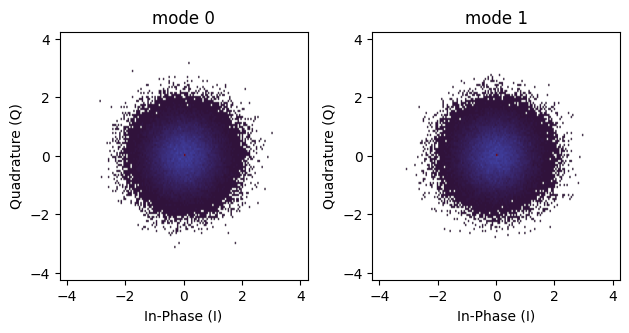

In [9]:
# local oscillator (LO) parameters:
FO  = -128e6                 # frequency offset
paramLO = parameters()
paramLO.P = 10              # power in dBm
paramLO.lw = 100e3          # laser linewidth
paramLO.RIN_var = 0
paramLO.Ns = len(sigCh)
paramLO.Fs = Fs
paramLO.seed = 789 # random seed for noise generation
paramLO.freqShift = 0 + FO  # downshift of the channel to be demodulated add frequency offset

# generate CW laser LO field
sigLO = basicLaserModel(paramLO)

print('Local oscillator P: %.2f dBm, lw: %.2f kHz, FO: %.2f MHz\n'\
      %(paramLO.P, paramLO.lw/1e3, FO/1e6))

# polarization multiplexed coherent optical receiver

# Frontend parameters
paramFE = parameters()
paramFE.Fs = Fs
paramFE.polRotation = np.pi/3    # input polarization rotation angle
paramFE.pdl = 0                  # Polarization dependent loss
paramFE.polDelay = 4e-12         # Polarization delay
paramFE.phaseImbX = 0*np.pi/180  # IQ phase imbalance polarization X in radians
paramFE.phaseImbY = 0*np.pi/180  # IQ phase imbalance polarization Y in radians
paramFE.ampImbX = 0              # IQ amplitude imbalance polarization X in dB
paramFE.ampImbY = 0              # IQ amplitude imbalance polarization Y in dB

# photodiodes parameters
paramPD = parameters()
paramPD.B = Rs
paramPD.Fs = Fs    
paramPD.ideal = True
paramPD.seed = 1011

sigRx = pdmCoherentReceiver(sigCh, sigLO, paramFE, paramPD)

# plot received constellations
pconst(sigRx[0::SpS,:], R=3);

Matched filtering took 0.75 seconds.


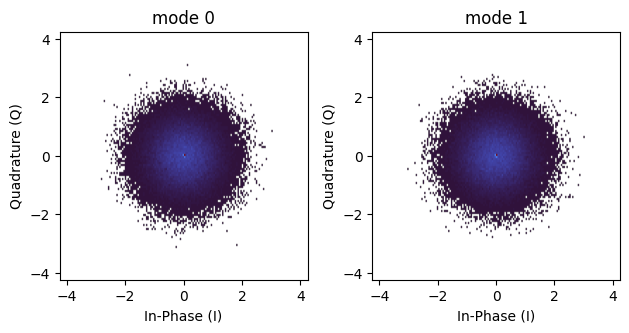

In [10]:
# Rx filtering

# Matched filtering
paramRxPulse = parameters()
paramRxPulse.SpS = SpS
paramRxPulse.nFilterTaps = nFilterTaps
paramRxPulse.rollOff = rollOff
paramRxPulse.pulseType = "rrc"
pulse = pulseShape(paramRxPulse) 

start = time.time()
sigRx = firFilter(pulse, sigRx)
end = time.time()
timeMF = end - start
print(f"Matched filtering took {timeMF:.2f} seconds.")

# plot constellations after matched filtering
pconst(sigRx[0::SpS,:], R=3);

In [11]:
# decimation
paramDec = parameters()
paramDec.SpSin  = SpS
paramDec.SpSout = 2

start = time.time()
sigRx = decimate(sigRx, paramDec)
end = time.time()
timeDec = end - start
print(f"Decimation took {timeDec:.2f} seconds.")

Decimation took 0.13 seconds.


Running CD compensation...
CD filter length: 46 taps, FFT size: 64


CD compensation took 0.38 seconds.


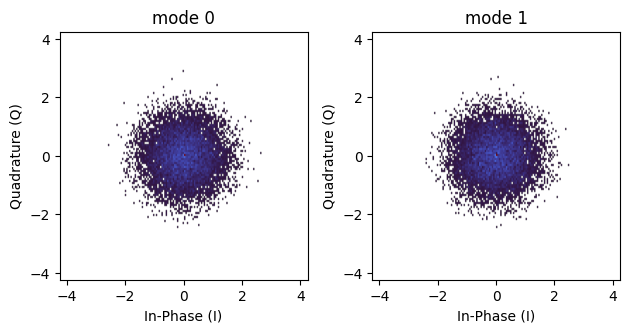

In [12]:
# CD compensation
paramEDC = parameters()
paramEDC.L = paramCh.Ltotal
paramEDC.D = paramCh.D
paramEDC.Fc = paramCh.Fc
paramEDC.Rs = Rs
paramEDC.Fs = 2*Rs

start = time.time()
sigRx = edc(sigRx, paramEDC)
end = time.time()
timeCDcomp = end - start
print(f"CD compensation took {timeCDcomp:.2f} seconds.")

# plot constellations after CD compensation
pconst(sigRx[0::SpS,:], R=3);

# re-synchronization with transmitted sequences
symbRx = symbolSync(sigRx, symbTx, 2)

In [13]:
# Power Normalizatino

x = pnorm(sigRx)
d = pnorm(symbRx)

Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.033646.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.022335.
rde - training stage #1
rde MSE = 0.012866.


Adaptive equalization took 36.89 seconds.


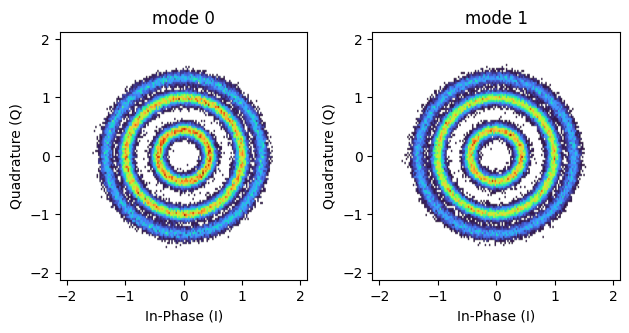

In [14]:
# adaptive equalization parameters
paramEq = parameters()
paramEq.nTaps = 35
paramEq.SpS = paramDec.SpSout
paramEq.numIter = 2
paramEq.storeCoeff = False
paramEq.M = M
paramEq.shapingFactor = 0
paramEq.L = [int(0.2*d.shape[0]), int(0.8*d.shape[0])]
paramEq.prgsBar = False

if M == 4:
    paramEq.alg = ['cma','cma'] # QPSK
    paramEq.mu = [5e-3, 1e-3]
else:
    paramEq.alg = ['da-rde','rde'] # M-QAM
    paramEq.mu = [5e-3, 5e-4] 

start = time.time()
y_EQ = mimoAdaptEqualizer(x, paramEq, d)
end = time.time()
timeEq = end - start
print(f"Adaptive equalization took {timeEq:.2f} seconds.")

#plot constellations after adaptive equalization
discard = 5000
pconst(y_EQ[discard:-discard,:], R=1.5);

Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24 128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 346.296 kHz


CPR took 4.07 seconds.


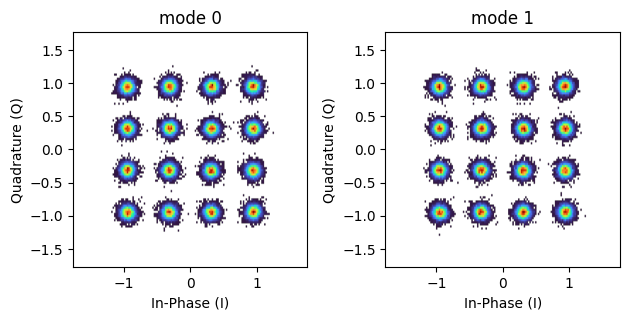

In [16]:
paramCPR = parameters()
paramCPR.alg = 'bps'
paramCPR.M   = M
paramCPR.constType = "qam"
paramCPR.shapingFactor = 0
paramCPR.N   = 25
paramCPR.B   = 64
paramCPR.returnPhases = False
paramCPR.Ts = 1/Rs

start = time.time()
y_CPR_1 = cpr(y_EQ, paramCPR)
end = time.time()
timeCPR = end - start
print(f"CPR took {timeCPR:.2f} seconds.")

discard = 5000

#plot constellations after CPR
pconst(y_CPR_1[discard:-discard,:]);

In [17]:
ind = np.arange(discard, d.shape[0]-discard)

# remove phase and polarization ambiguities for QPSK signals
if M == 4:   
    d = symbTx
    # find rotations after CPR and/or polarizations swaps possibly added at the output the adaptive equalizer:
    rot0 = [np.mean(pnorm(symbTx[ind,0])/pnorm(y_CPR_1[ind,0])), np.mean(pnorm(symbTx[ind,1])/pnorm(y_CPR_1[ind,0]))]
    rot1 = [np.mean(pnorm(symbTx[ind,1])/pnorm(y_CPR_1[ind,1])), np.mean(pnorm(symbTx[ind,0])/pnorm(y_CPR_1[ind,1]))]

    if np.argmax(np.abs(rot0)) == 1 and np.argmax(np.abs(rot1)) == 1:      
        y_CPR_ = y_CPR_1.copy() 
        # undo swap and rotation 
        y_CPR_1[:,0] = pnorm(rot1[np.argmax(np.abs(rot1))]*y_CPR_[:,1]) 
        y_CPR_1[:,1] = pnorm(rot0[np.argmax(np.abs(rot0))]*y_CPR_[:,0])
    else:
        # undo rotation
        y_CPR_1[:,0] = pnorm(rot0[np.argmax(np.abs(rot0))]*y_CPR_1[:,0])
        y_CPR_1[:,1] = pnorm(rot1[np.argmax(np.abs(rot1))]*y_CPR_1[:,1])
        

BER, SER, SNR = fastBERcalc(y_CPR_1[ind,:], d[ind,:], M, 'qam',px=paramSymb.px)
GMI, NGMI = monteCarloGMI(y_CPR_1[ind,:], d[ind,:], M, 'qam',px=paramSymb.px)
MI       = monteCarloMI(y_CPR_1[ind,:], d[ind,:], M, 'qam',px=paramSymb.px)
EVM      = calcEVM(y_CPR_1[ind,:], M, 'qam', d[ind,:])

print('      pol.X      pol.Y      ')
print(' SER: %.2e,  %.2e'%(SER[0], SER[1]))
print(' BER: %.2e,  %.2e'%(BER[0], BER[1]))
print(' SNR: %.2f dB,  %.2f dB'%(SNR[0], SNR[1]))
print(' EVM: %.2f %%,    %.2f %%'%(EVM[0]*100, EVM[1]*100))
print('  MI: %.2f bits, %.2f bits'%(MI[0], MI[1]))
print(' GMI: %.2f bits, %.2f bits'%(GMI[0], GMI[1]))
print('NGMI: %.2f,      %.2f'%(NGMI[0], NGMI[1]))

      pol.X      pol.Y      
 SER: 1.11e-05,  1.11e-05
 BER: 2.78e-06,  2.78e-06
 SNR: 21.44 dB,  21.48 dB
 EVM: 0.72 %,    0.72 %
  MI: 4.00 bits, 4.00 bits
 GMI: 4.00 bits, 4.00 bits
NGMI: 1.00,      1.00


In [18]:
print(f"{'-'*42}")
print(f"| {'DSP execution time benchmark':<30} | {'Time':<5} |")
print(f"| {'-'*30} | {'-'*5} |")
print(f"| {'Matched filtering':<30} | {timeMF:.2f} s|")
print(f"| {'CD compensation':<30} | {timeCDcomp:.2f} s|")
print(f"| {'Decimation':<30} | {timeDec:.2f} s|")
print(f"| {'Adaptive equalization':<30} | {timeEq:.2f} s|")
print(f"| {'Carrier phase recovery':<30} | {timeCPR:.2f} s|")
print(f"{'-'*42}")
print(f"| {'Total':<30} | {timeMF + timeCDcomp + timeDec + timeEq + timeCPR:.2f} s|")
print(f"{'-'*42}")

------------------------------------------
| DSP execution time benchmark   | Time  |
| ------------------------------ | ----- |
| Matched filtering              | 0.75 s|
| CD compensation                | 0.38 s|
| Decimation                     | 0.13 s|
| Adaptive equalization          | 36.89 s|
| Carrier phase recovery         | 4.07 s|
------------------------------------------
| Total                          | 42.23 s|
------------------------------------------
